In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the CLEAN dataset
df = pd.read_csv('data/clean_diabetic_data.csv')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (98053, 92)


,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes,readmitted_1
0,15,1,1,7,3,59,0,18,0,0,...,True,True,False,False,False,False,False,False,True,True
1,25,1,1,7,2,11,5,13,2,0,...,False,True,False,False,False,False,False,True,True,False
2,35,1,1,7,2,44,1,16,0,0,...,True,True,False,False,False,False,False,False,True,False
3,45,1,1,7,1,51,0,8,0,0,...,False,True,False,False,False,False,False,False,True,False
4,55,2,1,2,3,31,6,16,0,0,...,False,True,False,False,False,False,False,True,True,True


In [20]:
# 1. Separate the Target (y) from the Features (X)
# 'readmitted' is predictor
y = df['readmitted_1']

# X is everything ELSE (drop 'readmitted')
X = df.drop('readmitted_1', axis=1)

# 2. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes to verify the split
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (78442, 91)
Testing Data Shape: (19611, 91)


Confusion Matrix:
[[8189 2243]
 [5223 3956]]

Classification Report:
              precision    recall  f1-score   support

       False       0.61      0.78      0.69     10432
        True       0.64      0.43      0.51      9179

    accuracy                           0.62     19611
   macro avg       0.62      0.61      0.60     19611
weighted avg       0.62      0.62      0.61     19611



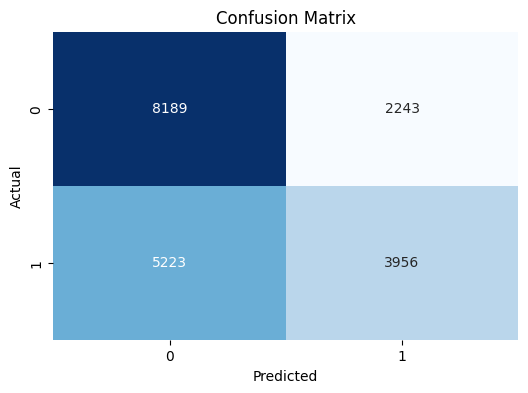

In [26]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Generate the Confusion Matrix
# This shows:
# [True Negatives, False Positives]
# [False Negatives, True Positives]
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# 2. Generate the full report
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# 3. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# 3. Predict on the test set
rf_predictions = rf_model.predict(X_test)

# 4. Evaluate
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy*100:.2f}%")

# 5. Show the new Classification Report
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, rf_predictions))

Training Random Forest...
Random Forest Accuracy: 62.80%

Classification Report (Random Forest):
              precision    recall  f1-score   support

       False       0.63      0.72      0.67     10432
        True       0.62      0.52      0.57      9179

    accuracy                           0.63     19611
   macro avg       0.63      0.62      0.62     19611
weighted avg       0.63      0.63      0.62     19611



                     Feature  Importance
5         num_lab_procedures    0.102252
7            num_medications    0.089828
4           time_in_hospital    0.065839
0                        age    0.055622
2   discharge_disposition_id    0.048129
11          number_diagnoses    0.045234
6             num_procedures    0.042285
91              total_visits    0.041391
10          number_inpatient    0.034961
1          admission_type_id    0.029972


/var/folders/v9/qx35lffs5xg9_5sb4g096g140000gn/T/ipykernel_6596/2560846838.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


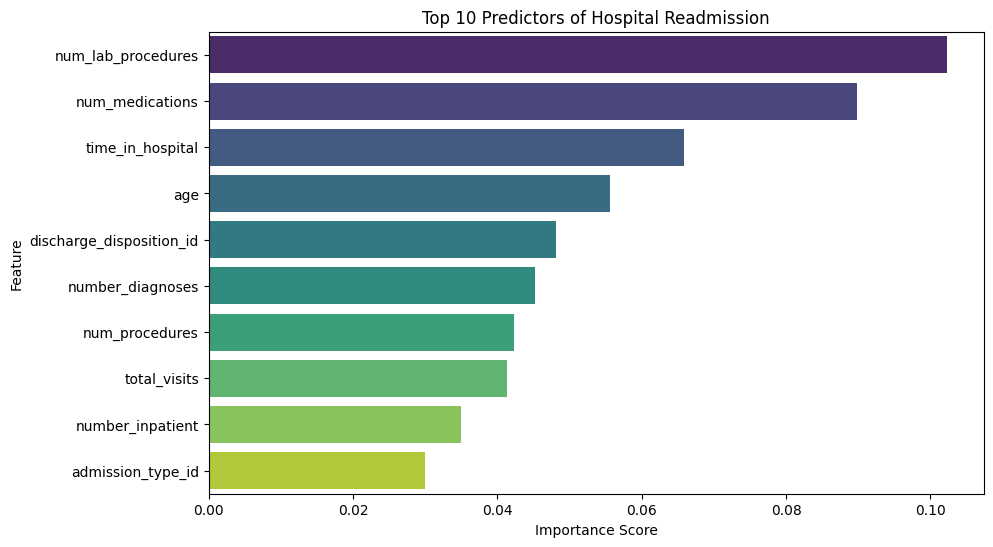

In [17]:
# Get feature importances from the trained model
importances = rf_model.feature_importances_

# Create a DataFrame to hold feature names and their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort by importance (highest on top)
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the top 10 most important features
print(feature_importance_df.head(10))

# Visualize the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Predictors of Hospital Readmission')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

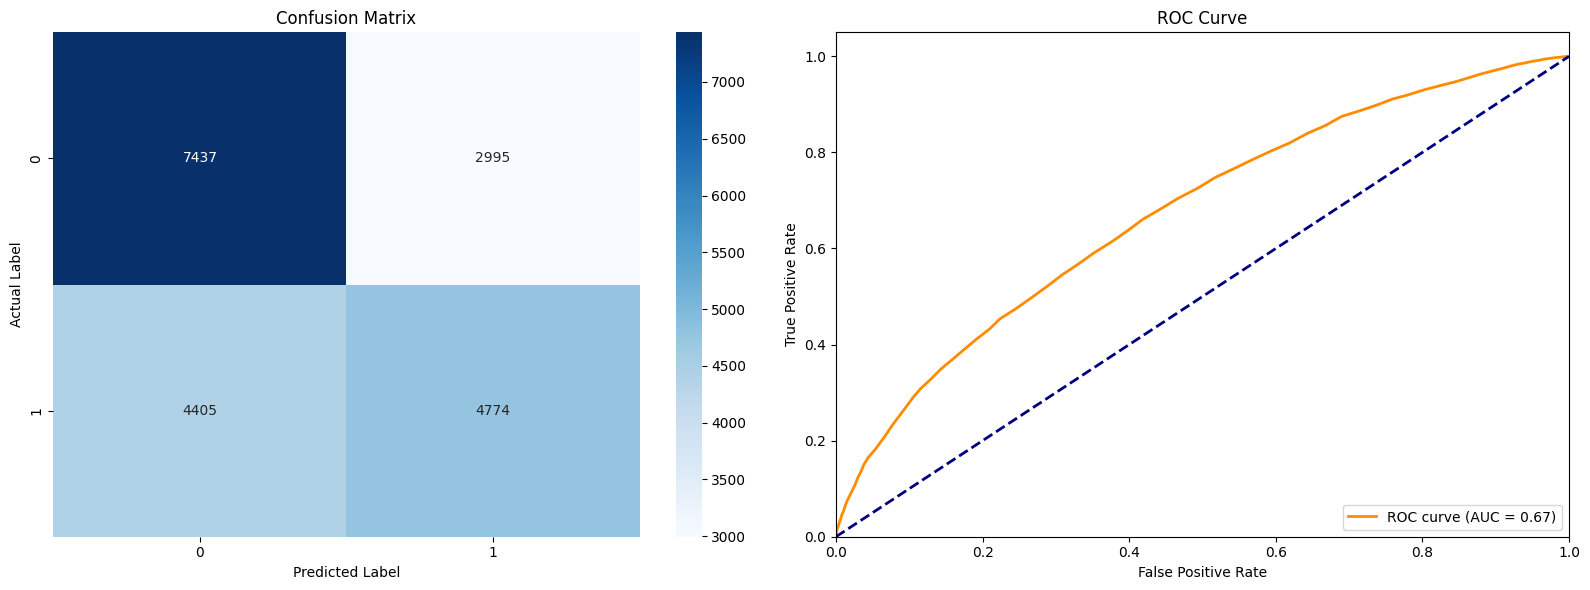

In [18]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the probability scores (needed for ROC Curve)
y_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 2. Setup the figure with 2 plots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_ylabel('Actual Label')
ax[0].set_xlabel('Predicted Label')

# --- Plot 2: ROC Curve ---
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()